In [55]:
import pandas as pd
data= pd.read_csv("https://raw.githubusercontent.com/maimunarahma/ai-ml/main/Nural_network/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [56]:
import numpy as np
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[cols] = data[cols].replace(0, np.nan)


In [57]:
# Fill missing values with median
data.fillna(data.median(), inplace=True)

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [58]:
# Split features and target
X = data.drop("Outcome", axis=1).values
y = data["Outcome"].values


In [59]:
# encoding
data["AgeGroup"] = pd.cut(data["Age"], bins=[20,30,40,50,60,80], labels=["A","B","C","D","E"])
data = pd.get_dummies(data, columns=["AgeGroup"])

In [60]:
# Train-test split (stratified)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [61]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
# converting to pytporch tensor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [63]:
# dividind into batch size using dataloader + shuffling

def get_loader(X, y, batch_size=32):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [64]:
# shallow NN
class ShallowNN(nn.Module):
    def __init__(self, input_size, hidden_size, activation="relu"):
        super().__init__()

        act = nn.ReLU() if activation == "relu" else nn.Sigmoid()

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            act,
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [65]:
# deep NN
class DeepNN(nn.Module):
    def __init__(self, input_size, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [66]:

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [],
    "val_acc": [] }

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))

    return history

In [67]:
train_loader = get_loader(X_train, y_train, batch_size=32)
val_loader = get_loader(X_test, y_test, batch_size=32)

In [68]:
# train shallow model
shallow_model = ShallowNN(input_size=X.shape[1], hidden_size=16, activation="relu")
shallow_history = train_model(shallow_model, train_loader, val_loader, epochs=50, lr=0.001)

In [69]:
# train deep model
deep_model = DeepNN(input_size=X.shape[1] ,dropout=0.3)
deep_history = train_model(deep_model, train_loader, val_loader, epochs=100, lr=0.0005)

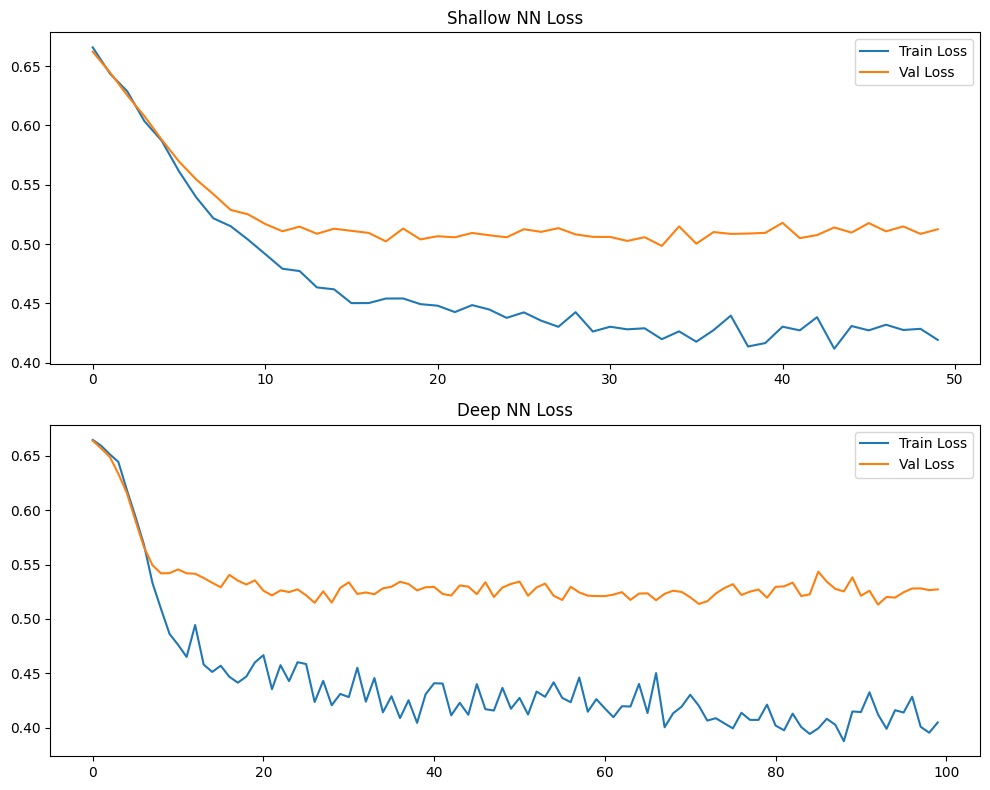

In [70]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(shallow_history["train_loss"], label="Train Loss")
ax[0].plot(shallow_history["val_loss"], label="Val Loss")
ax[0].set_title("Shallow NN Loss")
ax[0].legend()

ax[1].plot(deep_history["train_loss"], label="Train Loss")
ax[1].plot(deep_history["val_loss"], label="Val Loss")
ax[1].set_title("Deep NN Loss")
ax[1].legend()

plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import seaborn as sns

In [72]:
def get_predictions(model, X):
    model.eval()
    with torch.no_grad():
        preds = model(X)
    return preds.numpy()

shallow_preds = get_predictions(shallow_model, X_test)
deep_preds = get_predictions(deep_model, X_test)

In [73]:
def evaluate(y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob)
    }

shallow_metrics = evaluate(y_test, shallow_preds)
deep_metrics = evaluate(y_test, deep_preds)

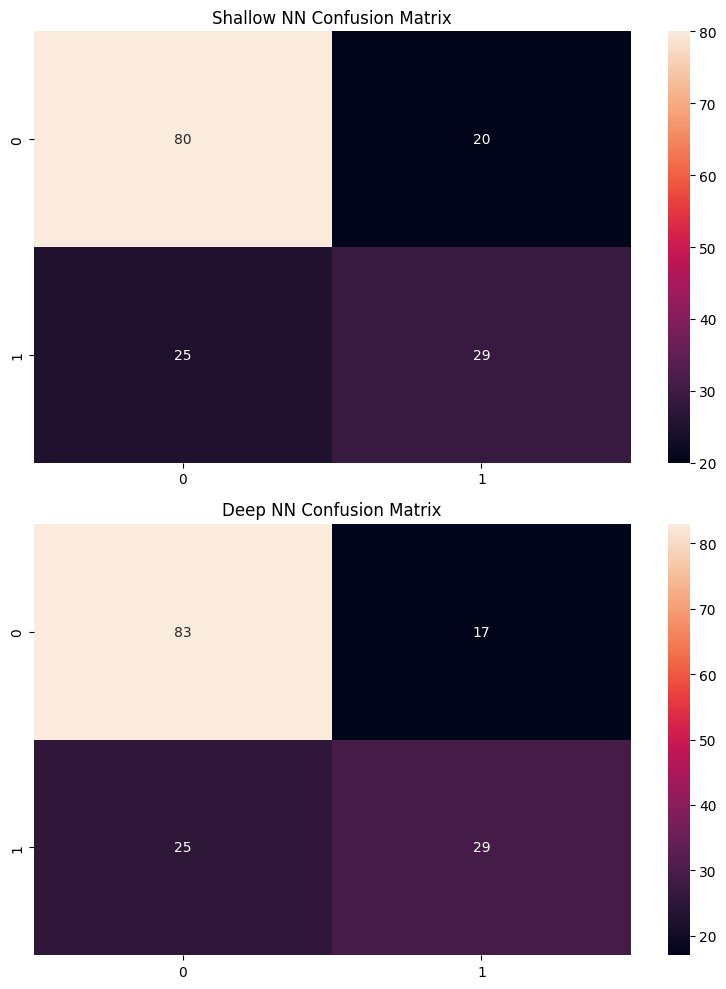

In [74]:
# confusion matrics
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

sns.heatmap(confusion_matrix(y_test, shallow_preds > 0.5),
            annot=True, fmt="d", ax=ax[0])
ax[0].set_title("Shallow NN Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, deep_preds > 0.5),
            annot=True, fmt="d", ax=ax[1])
ax[1].set_title("Deep NN Confusion Matrix")

plt.tight_layout()
plt.show()

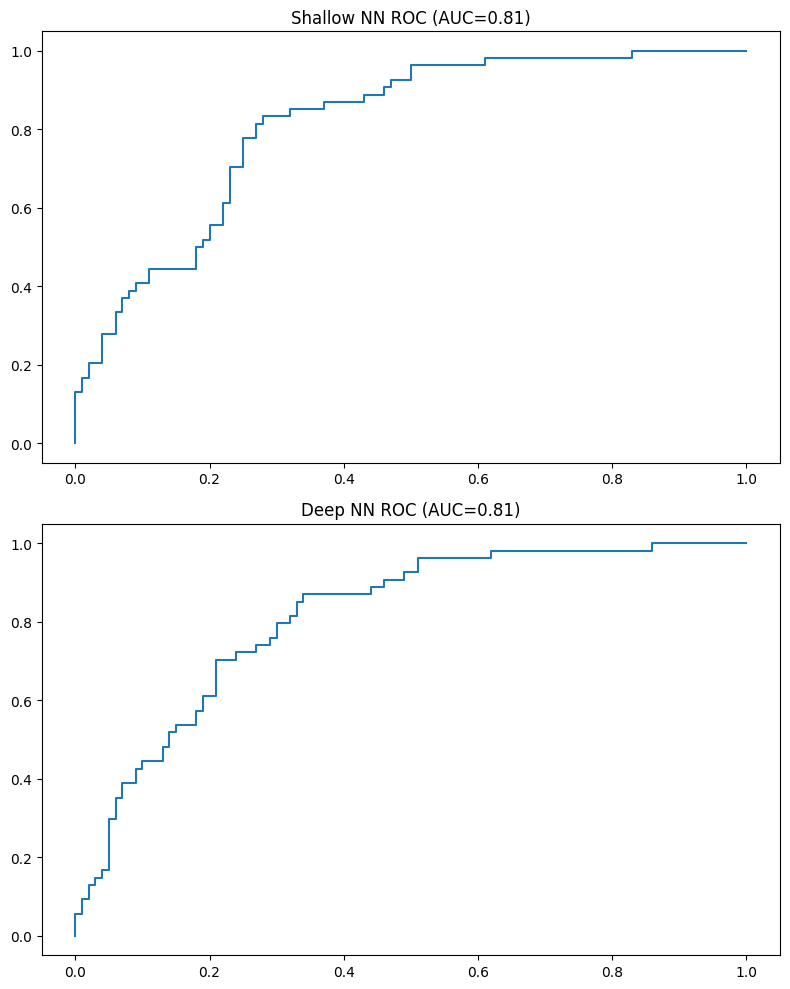

In [75]:
# ROC curve
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

fpr, tpr, _ = roc_curve(y_test, shallow_preds)
ax[0].plot(fpr, tpr)
ax[0].set_title(f"Shallow NN ROC (AUC={shallow_metrics['auc']:.2f})")

fpr, tpr, _ = roc_curve(y_test, deep_preds)
ax[1].plot(fpr, tpr)
ax[1].set_title(f"Deep NN ROC (AUC={deep_metrics['auc']:.2f})")

plt.tight_layout()
plt.show()

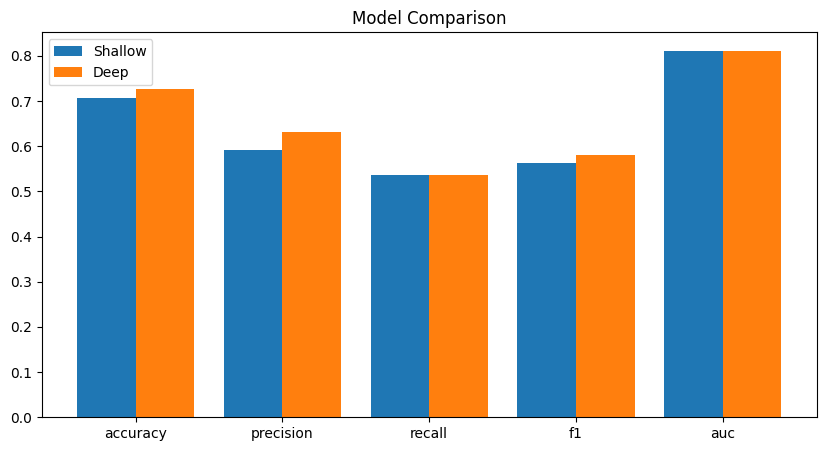

In [76]:
metrics = ["accuracy", "precision", "recall", "f1", "auc"]

shallow_vals = [shallow_metrics[m] for m in metrics]
deep_vals = [deep_metrics[m] for m in metrics]

x = np.arange(len(metrics))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, shallow_vals, 0.4, label="Shallow")
plt.bar(x + 0.2, deep_vals, 0.4, label="Deep")

plt.xticks(x, metrics)
plt.legend()
plt.title("Model Comparison")
plt.show()

In [77]:
print("SHALLOW NN")
print(shallow_model)

print("\nDEEP NN")
print(deep_model)

SHALLOW NN
ShallowNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

DEEP NN
DeepNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [78]:
# network structure
from pandas import DataFrame

shallow_structure = pd.DataFrame({
    "Layer": ["Input", "Hidden Layer 1", "Output"],
    "Details": [
        f"{X.shape[1]} Features",
        "Linear(8 → 16) + ReLU",
        "Linear(16 → 1) + Sigmoid"
    ]
})

print("SHALLOW NETWORK STRUCTURE")
display(shallow_structure)

SHALLOW NETWORK STRUCTURE


,Layer,Details
0,Input,8 Features
1,Hidden Layer 1,Linear(8 → 16) + ReLU
2,Output,Linear(16 → 1) + Sigmoid


In [79]:
deep_structure = pd.DataFrame({
    "Layer": [
        "Input",
        "Hidden Layer 1",
        "Hidden Layer 2",
        "Hidden Layer 3",
        "Output"
    ],
    "Details": [
        f"{X.shape[1]} Features",
        "Linear(8 → 64) + ReLU + Dropout(0.3)",
        "Linear(64 → 32) + ReLU + Dropout(0.3)",
        "Linear(32 → 16) + ReLU",
        "Linear(16 → 1) + Sigmoid"
    ]
})

print("DEEP NETWORK STRUCTURE")
display(deep_structure)

DEEP NETWORK STRUCTURE


,Layer,Details
0,Input,8 Features
1,Hidden Layer 1,Linear(8 → 64) + ReLU + Dropout(0.3)
2,Hidden Layer 2,Linear(64 → 32) + ReLU + Dropout(0.3)
3,Hidden Layer 3,Linear(32 → 16) + ReLU
4,Output,Linear(16 → 1) + Sigmoid


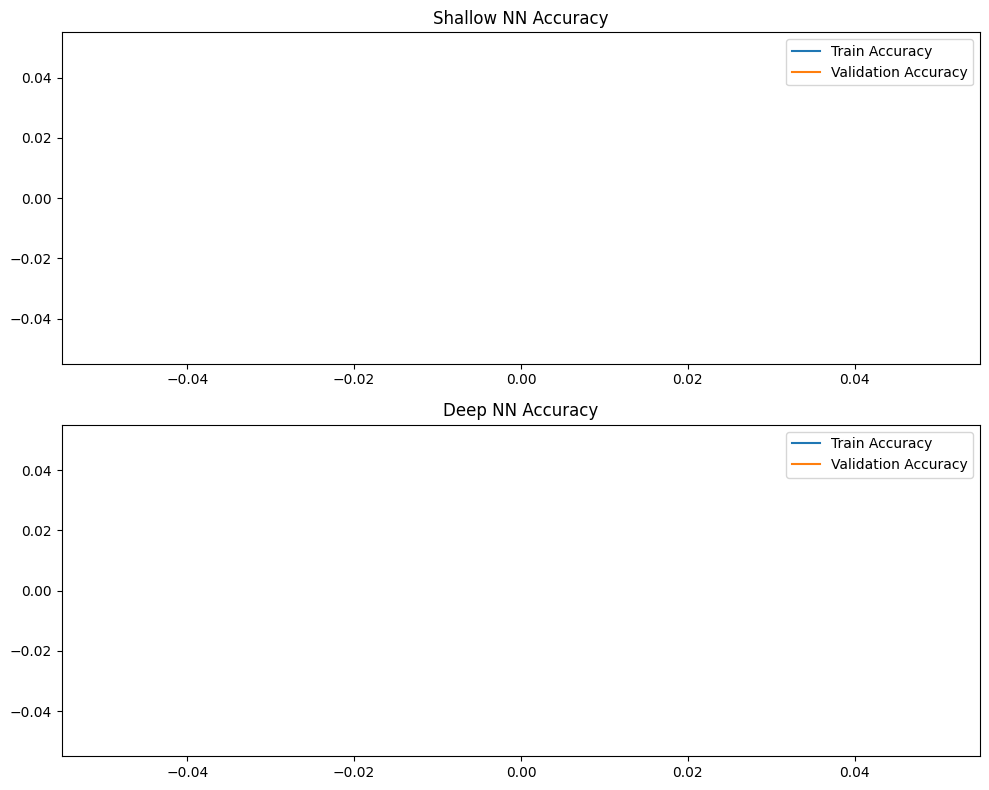

In [80]:
fig, ax = plt.subplots(2,1, figsize=(10,8))

ax[0].plot(shallow_history["train_acc"], label="Train Accuracy")
ax[0].plot(shallow_history["val_acc"], label="Validation Accuracy")
ax[0].set_title("Shallow NN Accuracy")
ax[0].legend()

ax[1].plot(deep_history["train_acc"], label="Train Accuracy")
ax[1].plot(deep_history["val_acc"], label="Validation Accuracy")
ax[1].set_title("Deep NN Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

### Performance Interpretation and Analysis

The Shallow Neural Network outperformed the Deep Neural Network in terms of Accuracy, Precision, Recall, and F1-Score on the test dataset. Although the Deep Neural Network achieved a slightly higher AUC score, the improvement was marginal and did not translate into better overall classification performance. These results suggest that the additional hidden layers did not provide a significant learning advantage for this relatively small tabular dataset. The lower performance of the Deep Neural Network may indicate mild overfitting or unnecessary model complexity, while the Shallow Neural Network demonstrated better generalization and more effective learning from the available data.
